In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

df = pd.read_csv("fact_player_season_master.csv")

In [34]:
def build_features(df):
    df = df.copy()
    df = df.sort_values(["player_id", "season_year"]).copy()

    if "targets" in df.columns and "rec_targets" not in df.columns:
        df["rec_targets"] = df["targets"]

    if "receptions" in df.columns and "rec_receptions" not in df.columns:
        df["rec_receptions"] = df["receptions"]

    if "receiving_yards" in df.columns and "rec_yards" not in df.columns:
        df["rec_yards"] = df["receiving_yards"]

    if "receiving_touchdowns" in df.columns and "rec_touchdowns" not in df.columns:
        df["rec_touchdowns"] = df["receiving_touchdowns"]

    if "games_played" in df.columns and "rec_player_game_count" not in df.columns:
        df["rec_player_game_count"] = df["games_played"]

    needed_stat_cols = [
        "pass_yards", "pass_touchdowns", "pass_attempts", "pass_interceptions",
        "rush_yards", "rush_touchdowns", "rush_attempts",
        "rec_receptions", "rec_targets", "rec_yards", "rec_touchdowns",
        "rec_player_game_count"
    ]

    for col in needed_stat_cols:
        if col not in df.columns:
            df[col] = 0

    if "team_pass_yards" not in df.columns:
        team_pass = df.groupby(["team_name", "season_year"], as_index=False).agg({
            "pass_yards": "sum",
            "pass_touchdowns": "sum",
            "pass_attempts": "sum",
            "pass_interceptions": "sum"
        }).rename(columns={
            "pass_yards": "team_pass_yards",
            "pass_touchdowns": "team_pass_tds",
            "pass_attempts": "team_pass_attempts",
            "pass_interceptions": "team_pass_ints"
        })
        df = df.merge(team_pass, on=["team_name", "season_year"], how="left")

    if "team_rush_yards" not in df.columns:
        team_rush = df.groupby(["team_name", "season_year"], as_index=False).agg({
            "rush_yards": "sum",
            "rush_touchdowns": "sum",
            "rush_attempts": "sum"
        }).rename(columns={
            "rush_yards": "team_rush_yards",
            "rush_touchdowns": "team_rush_tds",
            "rush_attempts": "team_rush_attempts"
        })
        df = df.merge(team_rush, on=["team_name", "season_year"], how="left")

    df["fantasy_points"] = (
        df["pass_yards"].fillna(0) * 0.04 +
        df["pass_touchdowns"].fillna(0) * 4 +
        df["pass_interceptions"].fillna(0) * -2 +
        df["rush_yards"].fillna(0) * 0.1 +
        df["rush_touchdowns"].fillna(0) * 6 +
        df["rec_receptions"].fillna(0) * 1 +
        df["rec_yards"].fillna(0) * 0.1 +
        df["rec_touchdowns"].fillna(0) * 6
    )

    df["target_fantasy_points"] = df.groupby("player_id")["fantasy_points"].shift(-1)

    df["team_targets"] = df.groupby(["team_name", "season_year"])["rec_targets"].transform("sum")
    df["target_share"] = df["rec_targets"] / df["team_targets"].replace(0, np.nan)

    df["team_target_rank"] = df.groupby(["team_name", "season_year"])["rec_targets"].rank(
        method="first",
        ascending=False
    )

    df["is_wr1"] = (df["team_target_rank"] == 1).astype(int)
    df["is_top2"] = (df["team_target_rank"] <= 2).astype(int)

    df["num_receivers"] = df.groupby(["team_name", "season_year"])["rec_targets"].transform(
        lambda x: (x > 30).sum()
    )

    df["max_teammate_share"] = df.groupby(["team_name", "season_year"])["target_share"].transform(
        lambda x: x.nlargest(2).iloc[-1] if len(x) > 1 else x.iloc[0]
    )

    df["fp_prev"] = df.groupby("player_id")["fantasy_points"].shift(1)
    df["games_prev"] = df.groupby("player_id")["rec_player_game_count"].shift(1)

    df["targets_prev"] = df.groupby("player_id")["rec_targets"].shift(1)
    df["receptions_prev"] = df.groupby("player_id")["rec_receptions"].shift(1)
    df["rec_yards_prev"] = df.groupby("player_id")["rec_yards"].shift(1)
    df["rec_tds_prev"] = df.groupby("player_id")["rec_touchdowns"].shift(1)

    df["rush_yards_prev"] = df.groupby("player_id")["rush_yards"].shift(1)
    df["rush_tds_prev"] = df.groupby("player_id")["rush_touchdowns"].shift(1)

    df["team_pass_yards_prev"] = df.groupby("player_id")["team_pass_yards"].shift(1)
    df["team_pass_tds_prev"] = df.groupby("player_id")["team_pass_tds"].shift(1)
    df["team_pass_attempts_prev"] = df.groupby("player_id")["team_pass_attempts"].shift(1)
    df["team_pass_ints_prev"] = df.groupby("player_id")["team_pass_ints"].shift(1)

    df["team_rush_yards_prev"] = df.groupby("player_id")["team_rush_yards"].shift(1)
    df["team_rush_tds_prev"] = df.groupby("player_id")["team_rush_tds"].shift(1)
    df["team_rush_attempts_prev"] = df.groupby("player_id")["team_rush_attempts"].shift(1)

    df["target_share_prev"] = df.groupby("player_id")["target_share"].shift(1)
    df["team_target_rank_prev"] = df.groupby("player_id")["team_target_rank"].shift(1)
    df["is_wr1_prev"] = df.groupby("player_id")["is_wr1"].shift(1)
    df["is_top2_prev"] = df.groupby("player_id")["is_top2"].shift(1)
    df["num_receivers_prev"] = df.groupby("player_id")["num_receivers"].shift(1)
    df["max_teammate_share_prev"] = df.groupby("player_id")["max_teammate_share"].shift(1)

    df["fp_per_game_prev"] = df["fp_prev"] / df["games_prev"].replace(0, np.nan)
    df["yards_per_target_prev"] = df["rec_yards_prev"] / df["targets_prev"].replace(0, np.nan)
    df["catch_rate_prev"] = df["receptions_prev"] / df["targets_prev"].replace(0, np.nan)
    df["td_rate_prev"] = df["rec_tds_prev"] / df["targets_prev"].replace(0, np.nan)

    df["pass_rate_prev"] = df["team_pass_attempts_prev"] / (
        df["team_pass_attempts_prev"] + df["team_rush_attempts_prev"]
    ).replace(0, np.nan)

    df["team_yards_per_attempt_prev"] = (
        df["team_pass_yards_prev"] / df["team_pass_attempts_prev"].replace(0, np.nan)
    )

    df["team_td_rate_prev"] = (
        df["team_pass_tds_prev"] / df["team_pass_attempts_prev"].replace(0, np.nan)
    )

    df["team_td_total_prev"] = df["team_pass_tds_prev"] + df["team_rush_tds_prev"]

    df["fp_prev2"] = df.groupby("player_id")["fantasy_points"].shift(2)
    df["fp_prev3"] = df.groupby("player_id")["fantasy_points"].shift(3)
    df["fp_trend"] = df["fp_prev"] - df["fp_prev2"]
    df["fp_trend_3yr"] = df["fp_prev"] - df["fp_prev3"]

    first_season = df.groupby("player_id")["season_year"].transform("min")
    df["years_in_league"] = df["season_year"] - first_season + 1
    df["years_in_league_sq"] = df["years_in_league"] ** 2
    df["is_veteran"] = (df["years_in_league"] >= 6).astype(int)

    df["fp_roll_2"] = df.groupby("player_id")["fantasy_points"].transform(
        lambda x: x.shift(1).rolling(2).mean()
    )
    df["fp_roll_3"] = df.groupby("player_id")["fantasy_points"].transform(
        lambda x: x.shift(1).rolling(3).mean()
    )

    df["targets_roll_2"] = df.groupby("player_id")["rec_targets"].transform(
        lambda x: x.shift(1).rolling(2).mean()
    )
    df["yards_roll_2"] = df.groupby("player_id")["rec_yards"].transform(
        lambda x: x.shift(1).rolling(2).mean()
    )

    df["fp_std_3"] = df.groupby("player_id")["fantasy_points"].transform(
        lambda x: x.shift(1).rolling(3).std()
    )

    return df

In [35]:
df_fe = build_features(df)

df_fe = df_fe[df_fe["position"] == "WR"].copy()
df_fe = df_fe.dropna(subset=["fp_prev", "target_fantasy_points"])
df_fe = df_fe[df_fe["games_prev"].fillna(0) >= 8].copy()

print(df_fe.shape)
display(df_fe.head())

(1246, 280)


,player,player_id,position,team_name,franchise_id,season_year,pass_player_game_count,pass_accuracy_percent,pass_aimed_passes,pass_attempts,...,fp_trend,fp_trend_3yr,years_in_league,years_in_league_sq,is_veteran,fp_roll_2,fp_roll_3,targets_roll_2,yards_roll_2,fp_std_3
85,Steve Smith,837,WR,BLT,3,2014,NaN,NaN,NaN,NaN,...,NaN,NaN,2,4,0,NaN,NaN,NaN,NaN,NaN
86,Steve Smith,837,WR,BLT,3,2015,NaN,NaN,NaN,NaN,...,59.3,NaN,3,9,0,192.15,NaN,116.5,906.5,NaN
152,Andre Johnson,1319,WR,HST,13,2014,NaN,NaN,NaN,NaN,...,NaN,NaN,2,4,0,NaN,NaN,NaN,NaN,NaN
153,Andre Johnson,1319,WR,IND,14,2015,NaN,NaN,NaN,NaN,...,-83.1,NaN,3,9,0,238.15,NaN,158.5,1171.5,NaN
188,Anquan Boldin,1369,WR,SF,28,2014,1.0,0.0,1.0,1.0,...,NaN,NaN,2,4,0,NaN,NaN,NaN,NaN,NaN


In [36]:
df_model = df_fe.dropna(subset=["target_fantasy_points"]).copy()

max_year = df_model["season_year"].max()

train_df = df_model[df_model["season_year"] < max_year].copy()
test_df = df_model[df_model["season_year"] == max_year].copy()

print("Training rows:", train_df.shape[0])
print(f"Testing rows (predicting {max_year + 1}):", test_df.shape[0])

drop_cols = ["player", "player_id", "fantasy_points", "target_fantasy_points"]

X_train = pd.get_dummies(train_df.drop(columns=drop_cols), drop_first=True)
X_test = pd.get_dummies(test_df.drop(columns=drop_cols), drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df["target_fantasy_points"]
y_test = test_df["target_fantasy_points"]

model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    min_child_weight=10,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

rmse = np.sqrt(root_mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"{max_year + 1} Prediction RMSE:", round(rmse, 4))
print(f"{max_year + 1} Prediction R^2:", round(r2, 4))

Training rows: 1124
Testing rows (predicting 2025): 122
2025 Prediction RMSE: 53.8606
2025 Prediction R^2: 0.6258



Prediction analysis sample:


,player,season_year,actual_2025_fantasy_points,predicted_2025_fantasy_points,residual,abs_error
7076,DeAndre Hopkins,2024,67.0,102.723961,-35.723961,35.723961
7454,Keenan Allen,2024,182.7,161.712753,20.987247,20.987247
8540,Adam Thielen,2024,37.6,81.971336,-44.371336,44.371336
8953,Mike Evans,2024,84.8,192.688263,-107.888263,107.888263
9059,Brandin Cooks,2024,51.9,82.848595,-30.948595,30.948595
9295,Davante Adams,2024,222.9,174.760757,48.139243,48.139243
11399,Tyler Lockett,2024,67.1,88.900291,-21.800291,21.800291
11834,Stefon Diggs,2024,210.3,162.880722,47.419278,47.419278
12356,DeAndre Carter,2024,0.0,8.362131,-8.362131,8.362131
13144,Sterling Shepard,2024,84.0,33.149590,50.850410,50.850410



Top 10 Most Underpredicted Players (2025)


,player,actual_2025_fantasy_points,predicted_2025_fantasy_points,residual,abs_error
26584,Jaxon Smith-Njigba,361.9,201.032593,160.867407,160.867407
25176,Chris Olave,268.0,129.562485,138.437515,138.437515
25191,Michael Wilson,220.6,83.620514,136.979486,136.979486
25826,George Pickens,289.9,164.041061,125.858939,125.858939
23868,Marquise Brown,137.7,34.470894,103.229106,103.229106
26074,Wan'Dale Robinson,217.9,116.372505,101.527495,101.527495
25932,Puka Nacua,377.0,280.038544,96.961456,96.961456
25208,Amon-Ra St. Brown,324.0,239.937622,84.062378,84.062378
26284,Xavier Hutchinson,98.0,20.141771,77.858229,77.858229
24005,Rashid Shaheed,146.6,70.760834,75.839166,75.839166



Top 10 Most Overpredicted Players (2025)


,player,actual_2025_fantasy_points,predicted_2025_fantasy_points,residual,abs_error
13902,Tyreek Hill,53.5,225.337601,-171.837601,171.837601
20789,Calvin Ridley,47.3,159.243301,-111.943301,111.943301
24494,Jayden Reed,48.5,158.013016,-109.513016,109.513016
8953,Mike Evans,84.8,192.688263,-107.888263,107.888263
20567,Ray-Ray McCloud III,13.9,112.899368,-98.999368,98.999368
25486,Garrett Wilson,99.5,195.484695,-95.984695,95.984695
25156,Rashod Bateman,53.4,129.404175,-76.004175,76.004175
23824,Justin Jefferson,201.5,271.855988,-70.355988,70.355988
26327,Jordan Addison,135.1,205.042389,-69.942389,69.942389
25552,Jonathan Mingo,3.5,69.726791,-66.226791,66.226791



Top 10 Biggest Overall Misses (2025)


,player,actual_2025_fantasy_points,predicted_2025_fantasy_points,residual,abs_error
13902,Tyreek Hill,53.5,225.337601,-171.837601,171.837601
26584,Jaxon Smith-Njigba,361.9,201.032593,160.867407,160.867407
25176,Chris Olave,268.0,129.562485,138.437515,138.437515
25191,Michael Wilson,220.6,83.620514,136.979486,136.979486
25826,George Pickens,289.9,164.041061,125.858939,125.858939
20789,Calvin Ridley,47.3,159.243301,-111.943301,111.943301
24494,Jayden Reed,48.5,158.013016,-109.513016,109.513016
8953,Mike Evans,84.8,192.688263,-107.888263,107.888263
23868,Marquise Brown,137.7,34.470894,103.229106,103.229106
26074,Wan'Dale Robinson,217.9,116.372505,101.527495,101.527495



Residual Summary
count    122.000000
mean      -1.223133
std       54.068755
min     -171.837601
25%      -32.802038
50%       -6.445463
75%       26.430906
max      160.867407
Name: residual, dtype: float64

Average actual fantasy points: 96.68
Average predicted fantasy points: 97.91
Average absolute error: 41.17


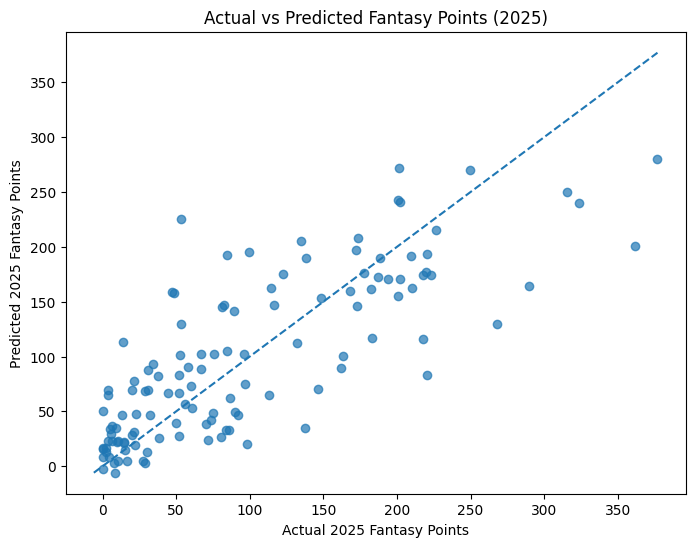

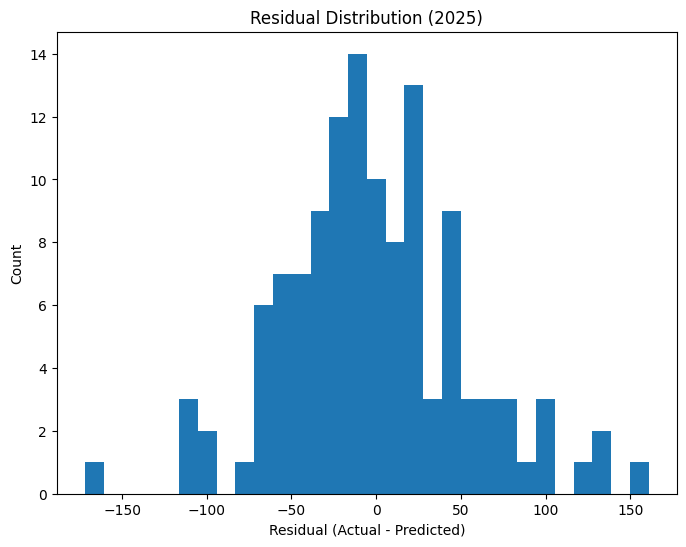

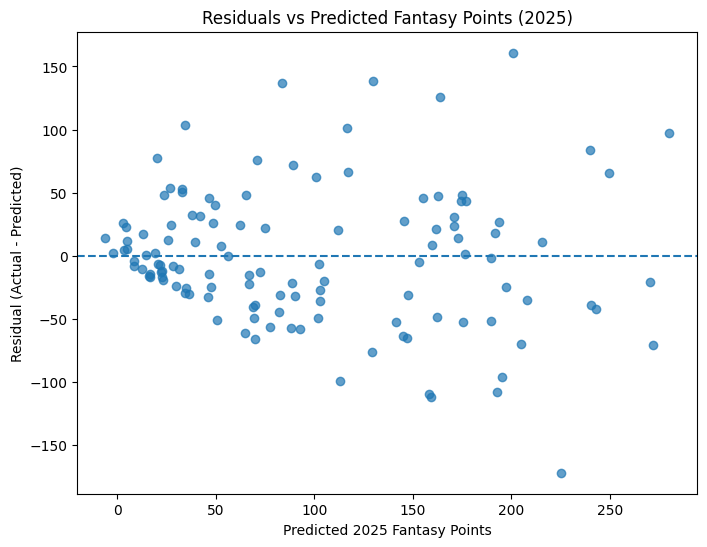


Predicted 2025 Fantasy Points Leaders


,player,season_year,actual_2025_fantasy_points,predicted_2025_fantasy_points,residual,abs_error
0,Puka Nacua,2024,377.00,280.038544,96.961456,96.961456
1,Justin Jefferson,2024,201.50,271.855988,-70.355988,70.355988
2,Zay Flowers,2024,249.30,270.108643,-20.808643,20.808643
3,Ja'Marr Chase,2024,315.60,249.798615,65.801385,65.801385
4,CeeDee Lamb,2024,200.90,243.007263,-42.107263,42.107263
5,Drake London,2024,201.90,240.535080,-38.635080,38.635080
6,Amon-Ra St. Brown,2024,324.00,239.937622,84.062378,84.062378
7,Tyreek Hill,2024,53.50,225.337601,-171.837601,171.837601
8,Nico Collins,2024,226.20,215.412949,10.787051,10.787051
9,Jauan Jennings,2024,173.30,208.099274,-34.799274,34.799274



Actual 2025 Fantasy Points Leaders


,player,actual_2025_fantasy_points,predicted_2025_fantasy_points,residual,abs_error
0,Puka Nacua,377.0,280.038544,96.961456,96.961456
1,Jaxon Smith-Njigba,361.9,201.032593,160.867407,160.867407
2,Amon-Ra St. Brown,324.0,239.937622,84.062378,84.062378
3,Ja'Marr Chase,315.6,249.798615,65.801385,65.801385
4,George Pickens,289.9,164.041061,125.858939,125.858939
5,Chris Olave,268.0,129.562485,138.437515,138.437515
6,Zay Flowers,249.3,270.108643,-20.808643,20.808643
7,Nico Collins,226.2,215.412949,10.787051,10.787051
8,Davante Adams,222.9,174.760757,48.139243,48.139243
9,Michael Wilson,220.6,83.620514,136.979486,136.979486


In [37]:
analysis_df = test_df[["player", "season_year"]].copy()
analysis_df["actual_2025_fantasy_points"] = y_test.values
analysis_df["predicted_2025_fantasy_points"] = preds
analysis_df["residual"] = (
    analysis_df["actual_2025_fantasy_points"] - analysis_df["predicted_2025_fantasy_points"]
)
analysis_df["abs_error"] = analysis_df["residual"].abs()

print("\nPrediction analysis sample:")
display(analysis_df.head(10))

underpredicted = analysis_df.sort_values("residual", ascending=False)
overpredicted = analysis_df.sort_values("residual", ascending=True)
largest_misses = analysis_df.sort_values("abs_error", ascending=False)

print("\nTop 10 Most Underpredicted Players (2025)")
display(
    underpredicted[
        ["player", "actual_2025_fantasy_points", "predicted_2025_fantasy_points", "residual", "abs_error"]
    ].head(10)
)

print("\nTop 10 Most Overpredicted Players (2025)")
display(
    overpredicted[
        ["player", "actual_2025_fantasy_points", "predicted_2025_fantasy_points", "residual", "abs_error"]
    ].head(10)
)

print("\nTop 10 Biggest Overall Misses (2025)")
display(
    largest_misses[
        ["player", "actual_2025_fantasy_points", "predicted_2025_fantasy_points", "residual", "abs_error"]
    ].head(10)
)

print("\nResidual Summary")
print(analysis_df["residual"].describe())

print("\nAverage actual fantasy points:", round(analysis_df["actual_2025_fantasy_points"].mean(), 2))
print("Average predicted fantasy points:", round(analysis_df["predicted_2025_fantasy_points"].mean(), 2))
print("Average absolute error:", round(analysis_df["abs_error"].mean(), 2))

plt.figure(figsize=(8, 6))
plt.scatter(
    analysis_df["actual_2025_fantasy_points"],
    analysis_df["predicted_2025_fantasy_points"],
    alpha=0.7
)

min_val = min(
    analysis_df["actual_2025_fantasy_points"].min(),
    analysis_df["predicted_2025_fantasy_points"].min()
)
max_val = max(
    analysis_df["actual_2025_fantasy_points"].max(),
    analysis_df["predicted_2025_fantasy_points"].max()
)

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual 2025 Fantasy Points")
plt.ylabel("Predicted 2025 Fantasy Points")
plt.title("Actual vs Predicted Fantasy Points (2025)")
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(analysis_df["residual"], bins=30)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Residual Distribution (2025)")
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(analysis_df["predicted_2025_fantasy_points"], analysis_df["residual"], alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted 2025 Fantasy Points")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Fantasy Points (2025)")
plt.show()

pred_2025_table = analysis_df.sort_values(
    "predicted_2025_fantasy_points",
    ascending=False
).reset_index(drop=True)

print("\nPredicted 2025 Fantasy Points Leaders")
display(pred_2025_table.head(15))

actual_2025_table = analysis_df.sort_values(
    "actual_2025_fantasy_points",
    ascending=False
).reset_index(drop=True)

print("\nActual 2025 Fantasy Points Leaders")
display(
    actual_2025_table[
        ["player", "actual_2025_fantasy_points", "predicted_2025_fantasy_points", "residual", "abs_error"]
    ].head(15)
)

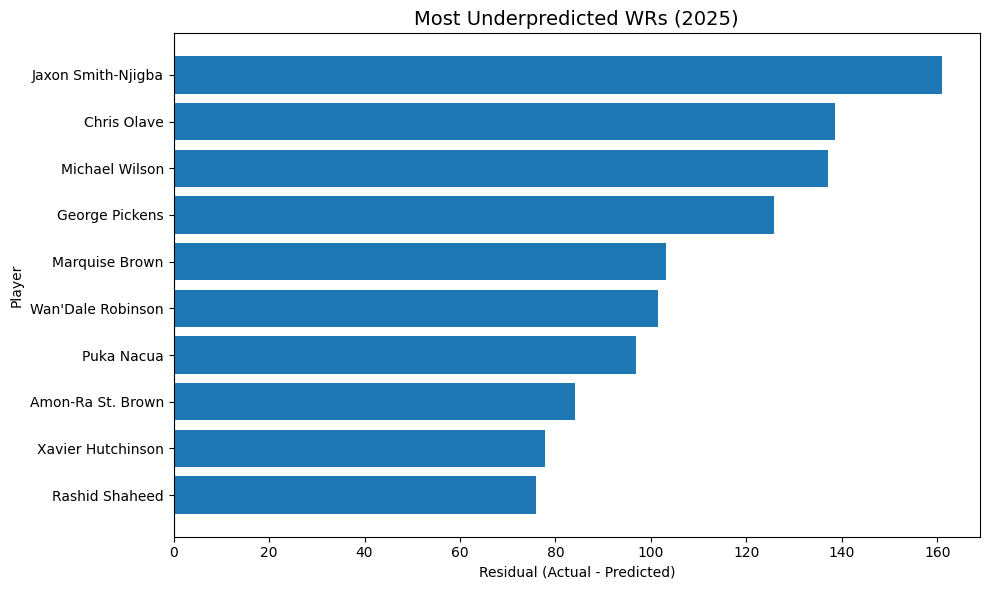

In [38]:
import matplotlib.pyplot as plt

# top underpredicted (actual > predicted)
top_under = analysis_df.sort_values("residual", ascending=False).head(10)

# sort so biggest is at top
top_under = top_under.sort_values("residual", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(top_under["player"], top_under["residual"])

plt.axvline(0)
plt.title("Most Underpredicted WRs (2025)", fontsize=14)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Player")

plt.tight_layout()
plt.show()

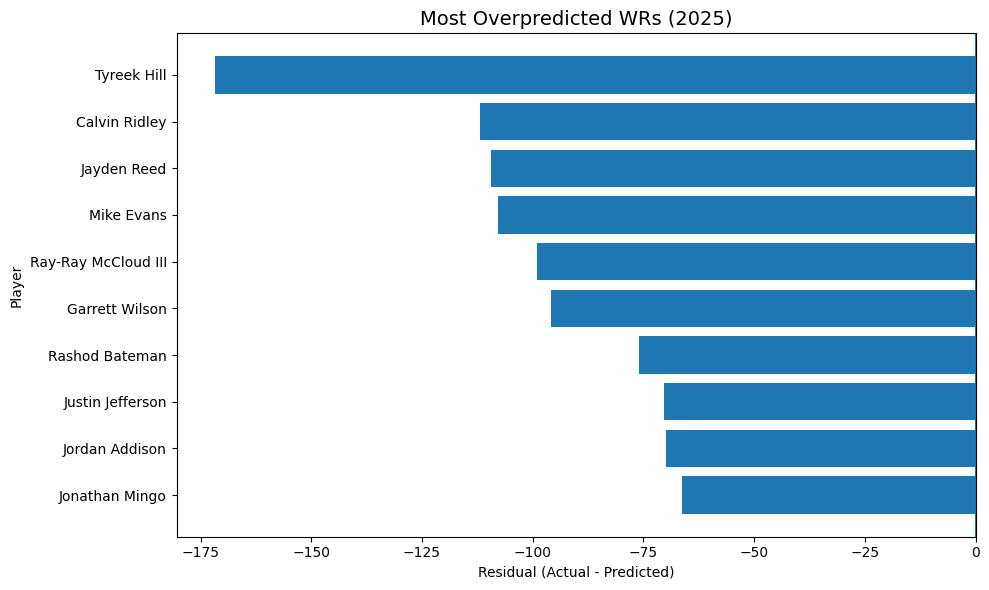

In [39]:
import matplotlib.pyplot as plt

# top overpredicted (actual < predicted)
top_over = analysis_df.sort_values("residual", ascending=True).head(10)

# sort so worst is at top
top_over = top_over.sort_values("residual", ascending=False)

plt.figure(figsize=(10, 6))

plt.barh(top_over["player"], top_over["residual"])

plt.axvline(0)
plt.title("Most Overpredicted WRs (2025)", fontsize=14)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Player")

plt.tight_layout()
plt.show()

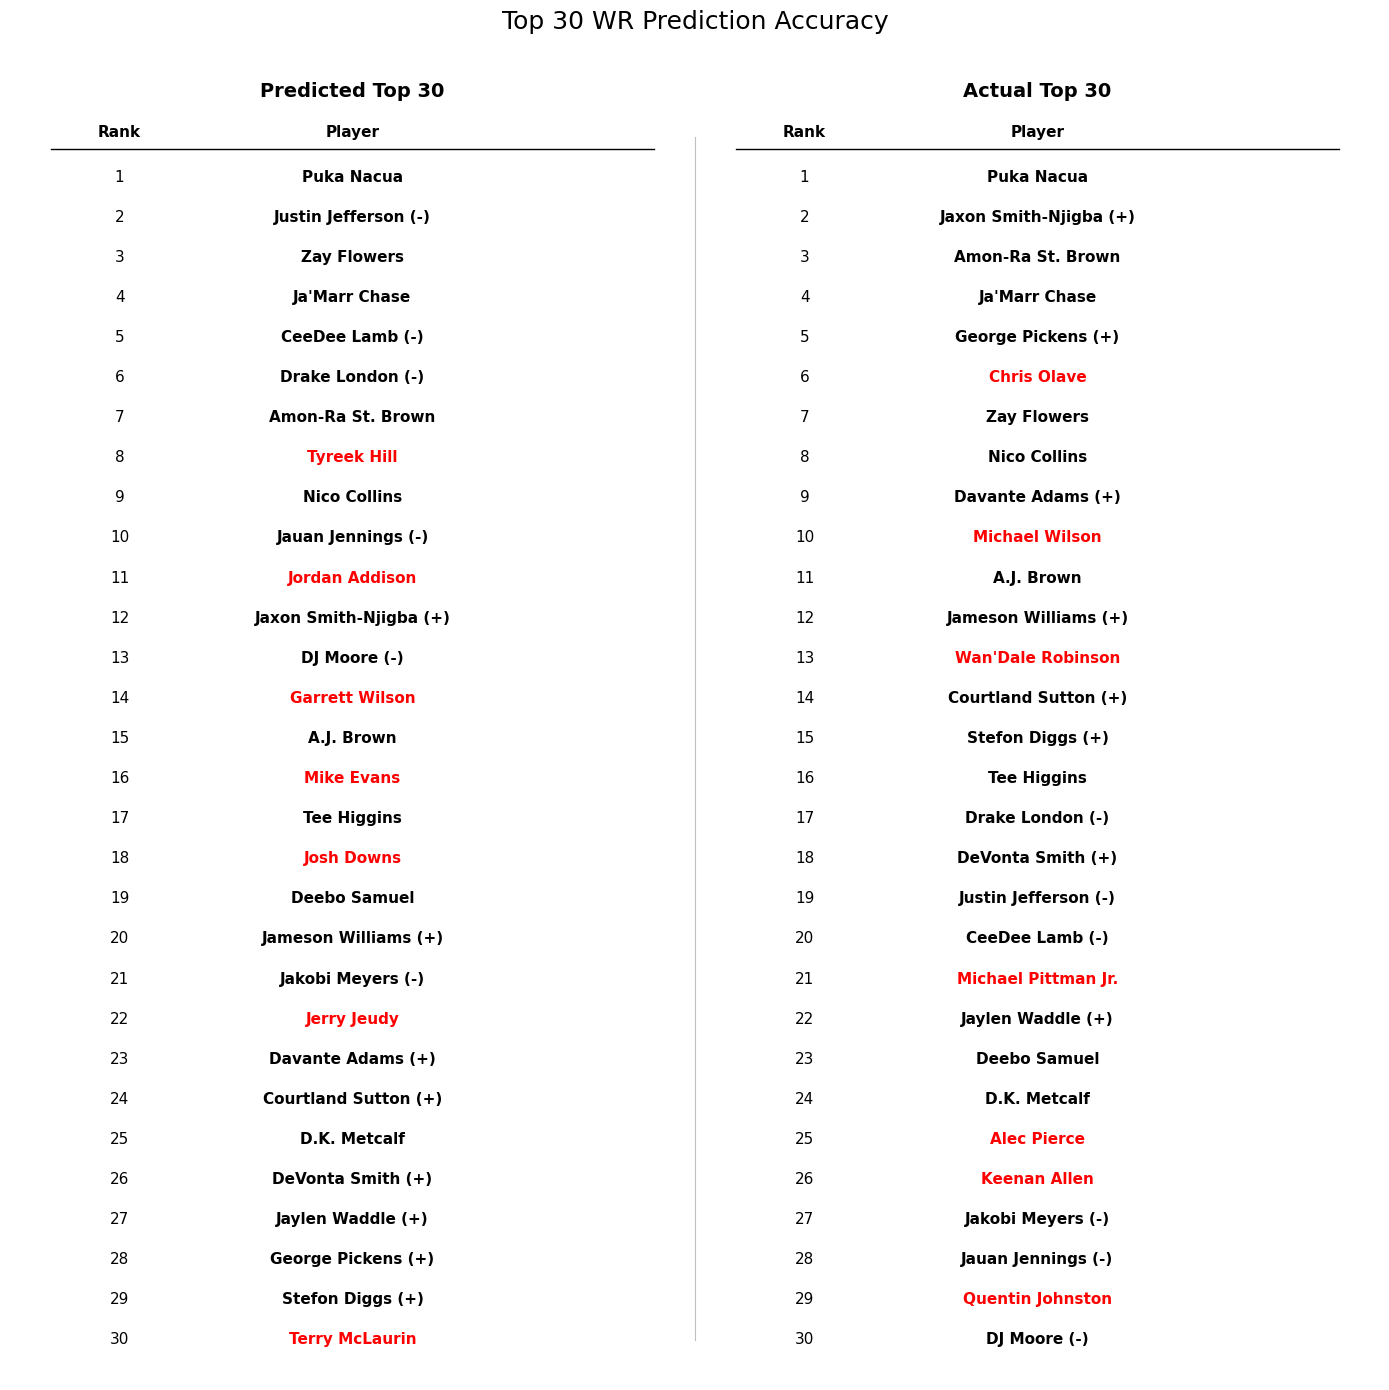

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

TOP_N = 30

# Build predicted top 30
top_pred = (
    actual_2025_table
    .sort_values("predicted_2025_fantasy_points", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
    .copy()
)
top_pred["pred_rank"] = top_pred.index + 1

# Build actual top 30
top_actual = (
    actual_2025_table
    .sort_values("actual_2025_fantasy_points", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
    .copy()
)
top_actual["actual_rank"] = top_actual.index + 1

# Lookup dictionaries
pred_rank_lookup = dict(zip(top_pred["player"], top_pred["pred_rank"]))
actual_rank_lookup = dict(zip(top_actual["player"], top_actual["actual_rank"]))

def format_label(player):
    pred_rank = pred_rank_lookup.get(player)
    actual_rank = actual_rank_lookup.get(player)

    # Red only if not on both lists
    color = "black" if (pred_rank is not None and actual_rank is not None) else "red"

    label = player

    # Only add +/- if player is on both lists and off by 5+ ranks
    if pred_rank is not None and actual_rank is not None:
        diff = actual_rank - pred_rank

        if diff <= -5:
            label = f"{player} (+)"
        elif diff >= 5:
            label = f"{player} (-)"

    return label, color

# Plot
fig, ax = plt.subplots(figsize=(14, 14))
ax.set_xlim(0, 1)
ax.set_ylim(TOP_N + 3, 0)
ax.axis("off")

# Title
plt.title("Top 30 WR Prediction Accuracy", fontsize=18, pad=20)

# Column titles
ax.text(0.25, 1.0, "Predicted Top 30", fontsize=14, fontweight="bold", ha="center")
ax.text(0.75, 1.0, "Actual Top 30", fontsize=14, fontweight="bold", ha="center")

# Headers
ax.text(0.08, 2.0, "Rank", fontsize=11, fontweight="bold", ha="center")
ax.text(0.25, 2.0, "Player", fontsize=11, fontweight="bold", ha="center")
ax.text(0.58, 2.0, "Rank", fontsize=11, fontweight="bold", ha="center")
ax.text(0.75, 2.0, "Player", fontsize=11, fontweight="bold", ha="center")

# Header lines
ax.plot([0.03, 0.47], [2.3, 2.3], linewidth=1, color="black")
ax.plot([0.53, 0.97], [2.3, 2.3], linewidth=1, color="black")

# Divider
ax.plot([0.5, 0.5], [2, TOP_N + 2], linewidth=0.8, color="gray", alpha=0.5)

# Rows
for i in range(TOP_N):
    y = i + 3

    pred_player = top_pred.loc[i, "player"]
    actual_player = top_actual.loc[i, "player"]

    pred_label, pred_color = format_label(pred_player)
    actual_label, actual_color = format_label(actual_player)

    # Predicted side
    ax.text(0.08, y, str(i + 1), fontsize=11, ha="center", va="center")
    ax.text(
        0.25, y, pred_label,
        fontsize=11,
        ha="center",
        va="center",
        color=pred_color,
        fontweight="bold"
    )

    # Actual side
    ax.text(0.58, y, str(i + 1), fontsize=11, ha="center", va="center")
    ax.text(
        0.75, y, actual_label,
        fontsize=11,
        ha="center",
        va="center",
        color=pred_color if False else actual_color,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get feature importance from model
importances = model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

# Sort and take top 10
top_features = feature_importance_df.sort_values(
    by="importance", ascending=False
).head(10)

# Reverse for horizontal bar chart (largest on top)
top_features = top_features[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])

plt.title("Top 10 Most Important Features (XGBoost Model)", fontsize=16, weight="bold")
plt.xlabel("Feature Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)

# Add values next to bars
for i, v in enumerate(top_features["importance"]):
    plt.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()


NameError: name 'model' is not defined